In [2]:
import numpy as np
import gymnasium as gym
import torch

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt
# The "ipympl" backend is better, as it allows for interactiveness, but on some installations it does not work, then use "inline"
%matplotlib ipympl
# %matplotlib inline  

# this way of importing allow to reload/refresh the module later with importlib.reload(policy)
import policy as policy 
import memory as mem
from feedforward import Feedforward

Load environment, policy and memory.

In [5]:
env = gym.make('Pendulum-v1', g=9.81, render_mode="human")
pi = policy.PDPolicy(env)
buffer = mem.Memory()

## Inspect the environment 

In [6]:
s , _ = env.reset()
for t in range(100):
    a = pi.get_action(s) 
    s_new, rew, term, trunc, _ = env.step(a)
    buffer.add_transition([s,a,rew,s_new, term, trunc])
    s = s_new

/home/junes/miniconda3/envs/RL6/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [7]:
transitions = buffer.get_all_transitions()
states = np.vstack(transitions[:,0])
actions = transitions[:,1]
rewards = transitions[:,2]

Plot the trajectory: (state, action, reward)
 
 The state is [position, velocity] 
 
 **changes are needed**

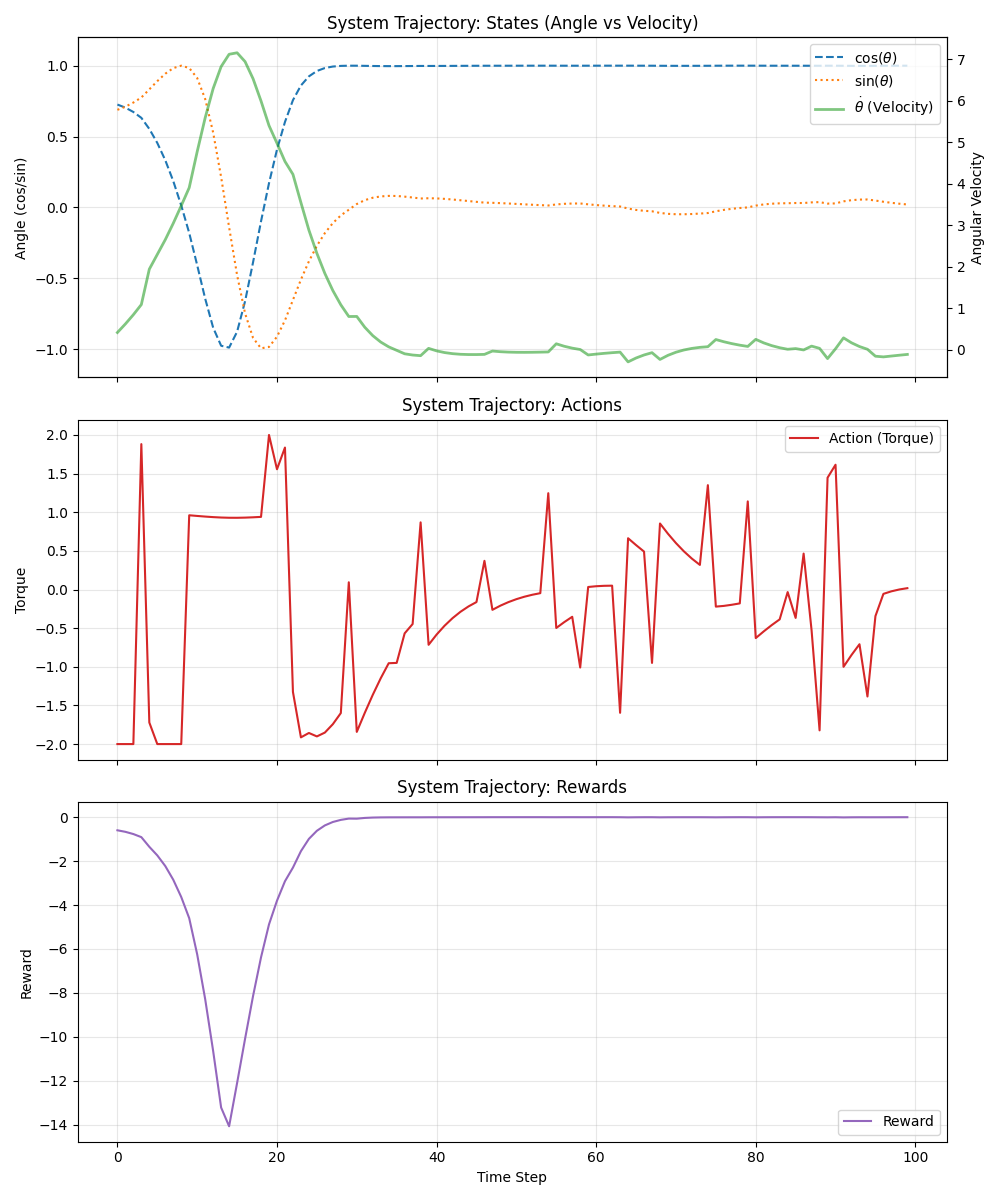

In [8]:
limit_steps = 500
if len(states) > limit_steps:
    states = states[:limit_steps]
    actions = actions[:limit_steps]
    rewards = rewards[:limit_steps]

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1 = axes[0]
line1 = ax1.plot(states[:, 0], label=r'$\cos(\theta)$', color='tab:blue', linestyle='--')
line2 = ax1.plot(states[:, 1], label=r'$\sin(\theta)$', color='tab:orange', linestyle=':')
ax1.set_ylabel("Angle (cos/sin)")
ax1.set_ylim([-1.2, 1.2])  
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line3 = ax2.plot(states[:, 2], label=r'$\dot{\theta}$ (Velocity)', color='tab:green', linewidth=2, alpha=0.6)
ax2.set_ylabel("Angular Velocity")
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
ax1.set_title("System Trajectory: States (Angle vs Velocity)")
axes[1].plot(actions, color='tab:red', label='Action (Torque)')
axes[1].set_title("System Trajectory: Actions")
axes[1].set_ylabel("Torque")
axes[1].set_ylim([-2.2, 2.2]) 
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[2].plot(rewards, color='tab:purple', label='Reward')
axes[2].set_title("System Trajectory: Rewards")
axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("Reward")
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Collect data

We do 500 rollouts a 100 timesteps with the black box policy. Nothing needs to be changed here.

In [9]:
env = gym.make('Pendulum-v1', g=9.81, render_mode=None) # switch off rendering
for ep in range(500):
    # start a larger range initial conditions to see enough of the statespace
    s, _ = env.reset(options={"y_init": 4.0})
    for t in range(100):
        a = pi.get_action(s) 
        s_new, rew, term, trunc, _ = env.step(a)
        buffer.add_transition([s,a,rew,s_new, term, trunc])
        s = s_new

In [10]:
buffer.size

50100

# Fit value function

The value function fitting class. Here, you need to fill in the blank parts

In [23]:
class ValueFunction(Feedforward):
    def __init__(self, observation_dim, hidden_sizes=[100,100]):
        super().__init__(input_size=observation_dim, hidden_sizes=hidden_sizes, output_size=1)
        
        # so this class is already a neural network, see feedforward.py        
        # add and optimizer here (e.g. Adam with lr = 0.0002, eps=0.000001)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.0002, eps=0.000001)
        
        # add a loss function here (MSE Loss is standard for Value Fitting)
        self.loss = torch.nn.MSELoss()
    
    def fit(self, observations, targets):
        # Add one training step here. 
        # The states are called here observations        
        self.optimizer.zero_grad()
        
        # Hints:          
        # convert the inputs into torch tensors with torch.from_numpy
        obs_tensor = torch.from_numpy(observations).float()
        target_tensor = torch.from_numpy(targets).float()
        
        # use self.forward(input) to make a prediction to be used in the loss
        prediction = self.forward(obs_tensor)
        
        # Calculate loss
        loss_val = self.loss(prediction, target_tensor)
        
        # Backpropagation
        loss_val.backward()
        self.optimizer.step()
        
        # return the current loss
        return loss_val.item()

In [24]:
valuefunc = ValueFunction(observation_dim=env.observation_space.shape[0])

Fitting routine of the value function. Fill in the blank parts.

In [25]:
plt_fit = []

Starting training...
Iter 0, Loss: 21.79971


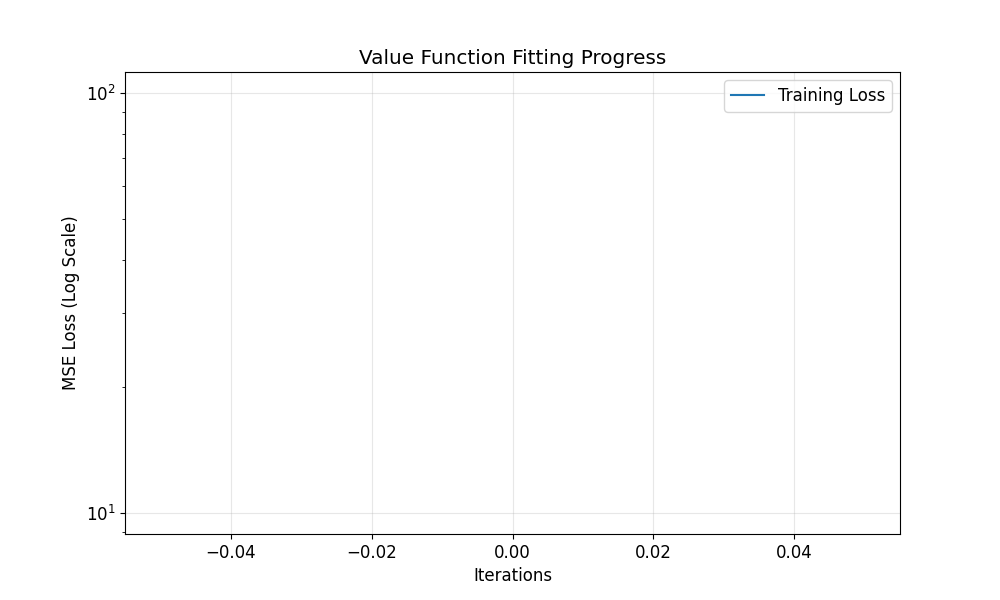

In [26]:

iter_fit = 1 # do at least 2000
gamma = 0.95

print("Starting training...")
for i in range(iter_fit):

    # sample from the replay buffer
    data = buffer.sample(batch=512)
    # each entry in data is (state,action,reward,next_state, term, trunc)    
    
    # Hints:
    # use can use np.stack to convert the array or arrays into one array
    # it is really important that you check the shapes of your arrays.
    
    # Extract states (Batch Size, State Dim)
    states = np.stack(data[:, 0])
    
    # Extract rewards (Batch Size, 1) - Reshape is crucial!
    rewards = np.stack(data[:, 2]).reshape(-1, 1)
    
    # Extract next states
    next_states = np.stack(data[:, 3])
    
    # Extract terminals (Optional for Pendulum as it's usually not terminal, but good practice)
    # dones = np.stack(data[:, 4]).reshape(-1, 1) # Not strictly needed if Done is always false
    
    # Calculate TD Target
    # V(s) target = r + gamma * V(s')
    # We use torch.no_grad() because we don't want to backprop through the target
    with torch.no_grad():
        next_states_tensor = torch.from_numpy(next_states).float()
        next_values = valuefunc(next_states_tensor).numpy()
    
    # TD Target calculation
    td_target = rewards + gamma * next_values 
    
    # optimize the least squared objective
    fit_loss = valuefunc.fit(states, td_target)
    
    plt_fit.append(fit_loss)
    
    if i % 200 == 0:
        print(f"Iter {i}, Loss: {fit_loss:.5f}")
    
# plot the loss
plt.figure(figsize=(10, 6))
plt.yscale("log")
plt.plot(range(len(plt_fit)), plt_fit, label='Training Loss')
plt.title("Value Function Fitting Progress")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualize

Visualization of the value function. Nothing needs to be changed here.

In [27]:
def plot_value_function(value_function):
    plt.rcParams.update({'font.size': 12})
    xxs =np.linspace(-np.pi/2,np.pi/2)
    yys =np.linspace(-3,3)
    XX,YY=np.meshgrid(xxs,yys)
    dots=np.asarray([np.cos(XX.ravel()),np.sin(XX.ravel()),YY.ravel()]).T
    print(dots.shape)
    # values = np.asarray(test_func(dots)).reshape(XX.shape)
    values =value_function.predict(dots).reshape(XX.shape)

    fig = plt.figure(figsize=[10,8])
    ax = fig.add_subplot(projection='3d')
    surf = ax.plot_surface(XX, YY, values, cmap=cm.coolwarm,
                           linewidth=0, antialiased=False)
    ax.view_init(elev=30, azim=45, roll=0)
    ax.set_xlabel('angle')
    ax.set_ylabel('angle velocity')
    ax.set_zlabel('value')
    # plt.colorbar(cmap=cm.coolwarm)
    return fig

In [28]:
fig = plot_value_function(valuefunc)
fig.savefig("value_approx_bf.png", bbox_inches="tight")

(2500, 3)
